# Präsentation — Modell-Grafiken (Regression & GAN)

Grafiken für den Modell-Teil:

1. **Architekturen**: Generator (U-Net) und Diskriminator (PatchGAN) als `summary()`.
2. **Lernkurven** für Regression (`reg_full_3`) und GAN (`gan_full_3`) — Loss und
   Metrik in getrennten Diagrammen.
3. **6er-Spektrogramm-Raster** Original / Bandbegrenzt / Copy-Up / Regression / GAN /
   Differenz GAN−Original.
4. **Crossover-Zoom** GAN vs. Original.
5. **Frequenzgänge einzelner STFT-Frames** für Regression-/GAN-Output.

Auswahl unten anpassen; `SAVE=True` schreibt PNGs/TXTs nach `praesentation/`.

In [1]:
import os
# MÜSSEN vor dem TensorFlow-Import gesetzt sein (oneDNN-Crash-Fix + leise Logs).
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import io
import contextlib
import pandas as pd
import tensorflow as tf

from bwe import config as cfg
from bwe.models.generator import Generator, build_unet
from bwe.models.discriminator import build_discriminator
from bwe.data.loaders import load_demo
from bwe.infer.reconstruct import model_from_fullband, baseline_from_fullband
from bwe.eval import plots as P

# >>> Export-Ziel für die Präsentations-Dateien <<<
SAVE   = True                # False = nur anzeigen, nichts speichern
ASSETS = Path(os.environ.get("BWE_PRAES_DIR",
    r"C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation"))

def save_fig(fig, name, subdir="plots"):
    """Figur als PNG in den Präsentations-Ordner schreiben (nur wenn SAVE=True)."""
    if SAVE:
        p = ASSETS / subdir / name
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=200, bbox_inches="tight")
        print("  gespeichert:", p)

def load_gen(run):
    """Generator-Gewichte eines Runs laden (bevorzugt die besten Val-Gewichte)."""
    d = cfg.CKPT_ROOT / run
    for n in ("best_generator.weights.h5", "generator.weights.h5"):
        if (d / n).exists():
            g = Generator()
            g(tf.zeros([1, cfg.N_BINS_NET, cfg.SEG_FRAMES, cfg.N_INPUT_CHANNELS]))
            g.load_weights(str(d / n))
            print("Gewichte:", d / n)
            return g
    raise FileNotFoundError(f"keine Generator-Gewichte unter {d}")

# >>> Finale Läufe <<<
REG_RUN = "reg_full_3"
GAN_RUN = "gan_full_3"

g_reg, g_gan = load_gen(REG_RUN), load_gen(GAN_RUN)
print(cfg.summary())

Gewichte: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\bwe_runs\reg_full_3\generator.weights.h5


Gewichte: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\bwe_runs\gan_full_3\best_generator.weights.h5
SR=32000 Hz | N_FFT=1024 HOP=256 | 31.250 Hz/Bin
Bins: full=513 net=512 | Cutoffs=(8000,) Hz | Standard 8000 Hz -> Bin 256
Copy-Up-Quellband = Bins 128..256
Segment: 128 Frames = 33536 Samples (~1.048 s)
DATA_ROOT=C:\Users\danyr\bwe_data\musdb18hq_32k


## 1. Architekturen

Generator = voll-faltendes 2D-U-Net (3 Kanäle rein: Re/Im/Frequenz-Koordinate, 2 linear
raus), Diskriminator = PatchGAN mit Spectral Normalization. Die `summary()`-Texte werden
zusätzlich als `.txt` exportiert (für Folien ggf. die Mermaid-Diagramme aus dem
Leitfaden §4 nutzen).

In [2]:
def summary_text(model):
    # Keras 3 rendert die Summary über rich; print_fn bekommt den fertigen Text.
    buf = []
    model.summary(print_fn=lambda *a, **k: buf.append(str(a[0])))
    return chr(10).join(buf)


gen_txt = summary_text(build_unet())
disc_txt = summary_text(build_discriminator())
print(gen_txt)
print(disc_txt)

if SAVE:
    d = ASSETS / "tabellen"
    d.mkdir(parents=True, exist_ok=True)
    (d / "generator_summary.txt").write_text(gen_txt, encoding="utf-8")
    (d / "diskriminator_summary.txt").write_text(disc_txt, encoding="utf-8")
    print("gespeichert:", d / "generator_summary.txt", "+ diskriminator_summary.txt")

Model: "bwe_unet"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_spec          │ (None, 512, None, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down0 (Sequential)  │ (None, 256, None, │      1,664 │ input_spec[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down1 (Sequential)  │ (None, 128, None, │     33,024 │ down0[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down2 (Sequential)  │ (None, 64, None,  │    131,584 │ d

## 2. Lernkurven

### Regression (`reg_full_3`)
Loss (RI+Mag, nur HF) und Val-Metrik (`val_lsd_hf` = spektraler Proxy auf Crops, nicht
die Wellenform-Metrik der Eval!) in getrennten Diagrammen. Val liegt *unter* Train,
weil Val ohne Augmentation und deterministisch läuft — kein Overfitting.

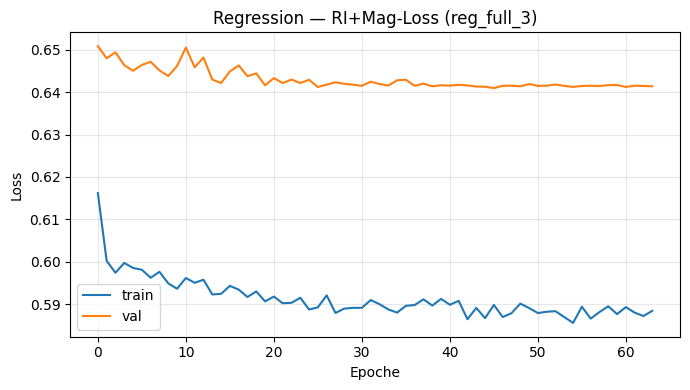

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\lernkurve_regression_loss.png


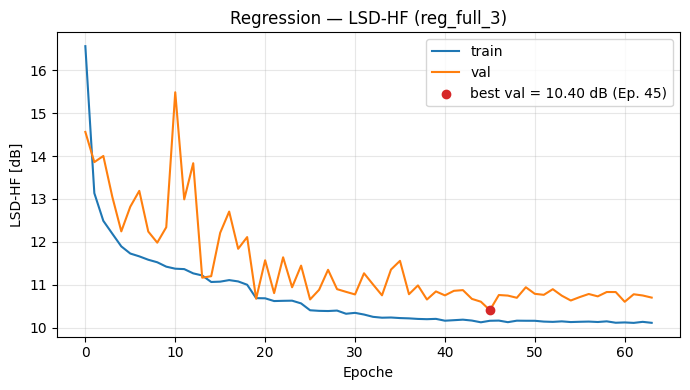

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\lernkurve_regression_lsd.png


In [3]:
df_reg = pd.read_csv(cfg.CKPT_ROOT / REG_RUN / "log.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_reg["epoch"], df_reg["loss"], label="train")
ax.plot(df_reg["epoch"], df_reg["val_loss"], label="val")
ax.set_title(f"Regression — RI+Mag-Loss ({REG_RUN})")
ax.set_xlabel("Epoche"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()
save_fig(fig, "lernkurve_regression_loss.png")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_reg["epoch"], df_reg["lsd_hf"], label="train")
ax.plot(df_reg["epoch"], df_reg["val_lsd_hf"], label="val")
best = df_reg["val_lsd_hf"].idxmin()
ax.scatter(df_reg["epoch"][best], df_reg["val_lsd_hf"][best], color="C3", zorder=3,
           label=f"best val = {df_reg['val_lsd_hf'][best]:.2f} dB (Ep. {int(df_reg['epoch'][best])})")
ax.set_title(f"Regression — LSD-HF ({REG_RUN})")
ax.set_xlabel("Epoche"); ax.set_ylabel("LSD-HF [dB]"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()
save_fig(fig, "lernkurve_regression_lsd.png")

### GAN (`gan_full_3`)

Losses (d_loss/adv im Equilibrium ≈ 2·ln 2 bzw. −ln 0,5 — **kein Qualitätsmaß**) und
die Val-Metrik getrennt. Die Kurve läuft über alle drei Resume-Läufe durch
(0→60→90→120 Epochen).

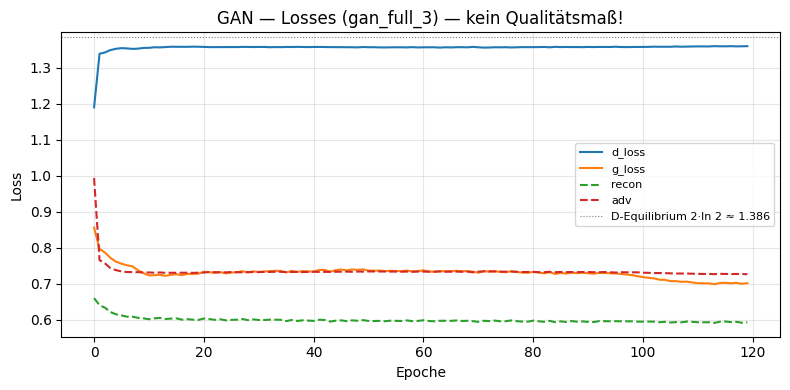

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\lernkurve_gan_losses.png


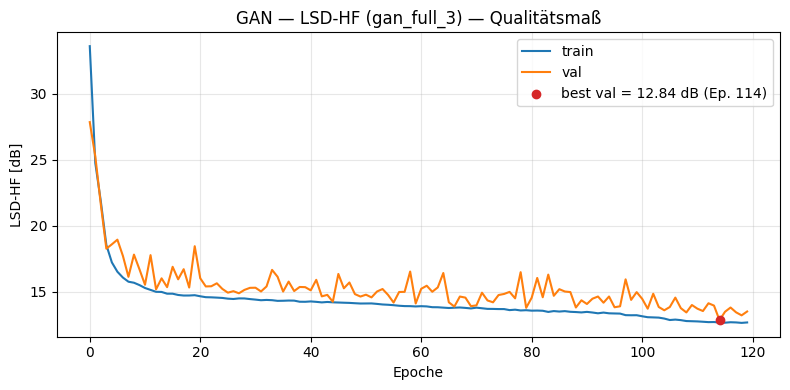

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\lernkurve_gan_lsd.png


In [4]:
df_gan = pd.read_csv(cfg.CKPT_ROOT / GAN_RUN / "log.csv")

fig, ax = plt.subplots(figsize=(8, 4))
for col, kw in [("d_loss", {}), ("g_loss", {}), ("recon", dict(ls="--")),
                ("adv", dict(ls="--"))]:
    if col in df_gan:
        ax.plot(df_gan["epoch"], df_gan[col], label=col, **kw)
ax.axhline(2 * np.log(2), color="grey", lw=0.8, ls=":",
           label="D-Equilibrium 2·ln 2 ≈ 1.386")
ax.set_title(f"GAN — Losses ({GAN_RUN}) — kein Qualitätsmaß!")
ax.set_xlabel("Epoche"); ax.set_ylabel("Loss"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()
save_fig(fig, "lernkurve_gan_losses.png")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_gan["epoch"], df_gan["lsd_hf"], label="train")
ax.plot(df_gan["epoch"], df_gan["val_lsd_hf"], label="val")
best = df_gan["val_lsd_hf"].idxmin()
ax.scatter(df_gan["epoch"][best], df_gan["val_lsd_hf"][best], color="C3", zorder=3,
           label=f"best val = {df_gan['val_lsd_hf'][best]:.2f} dB (Ep. {int(df_gan['epoch'][best])})")
ax.set_title(f"GAN — LSD-HF ({GAN_RUN}) — Qualitätsmaß")
ax.set_xlabel("Epoche"); ax.set_ylabel("LSD-HF [dB]"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()
save_fig(fig, "lernkurve_gan_lsd.png")

## 3.–5. Modellvergleich am Beispiel

Für jedes Beispiel: 6er-Spektrogramm-Raster, Crossover-Zoom GAN vs. Original und
Frequenzgänge einzelner Frames (Original / Regression / GAN — hier *unkomprimierte*
dB-Magnitude).

=== Al James - Schoolboy Facination ===


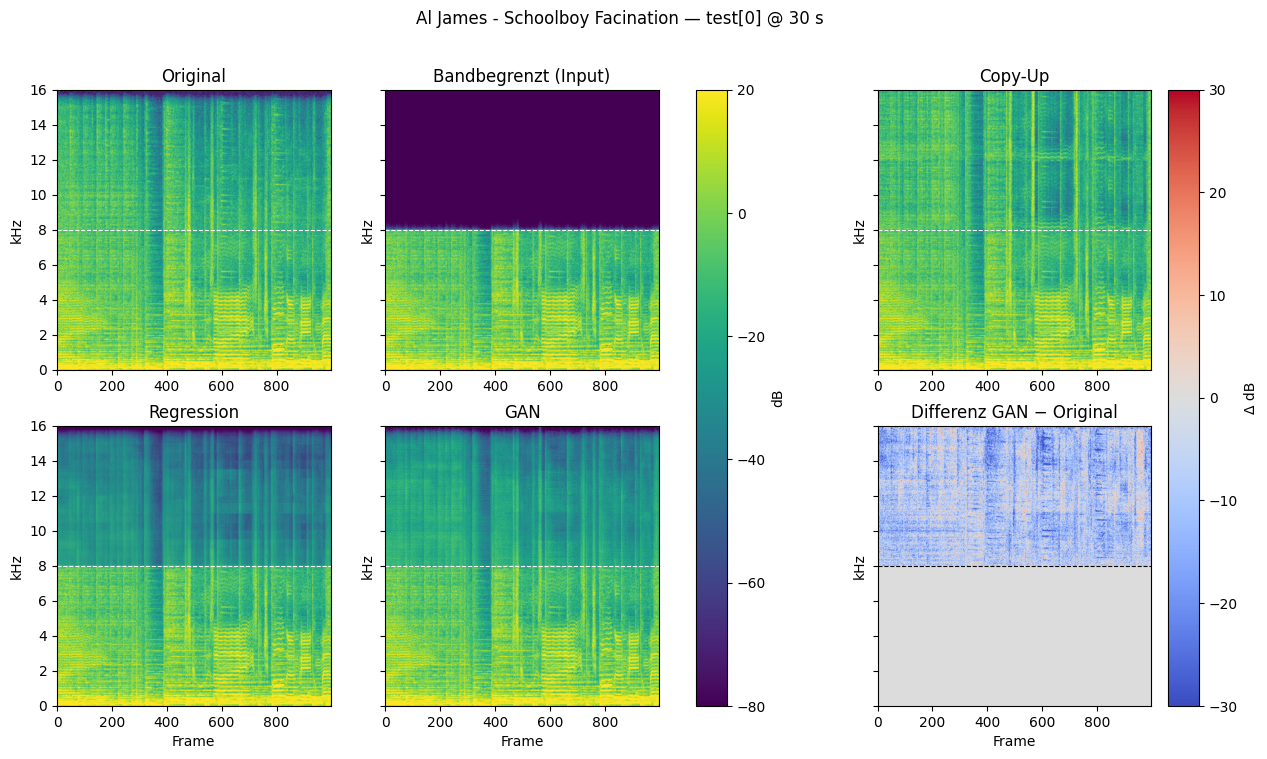

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\modelle_grid_test00.png


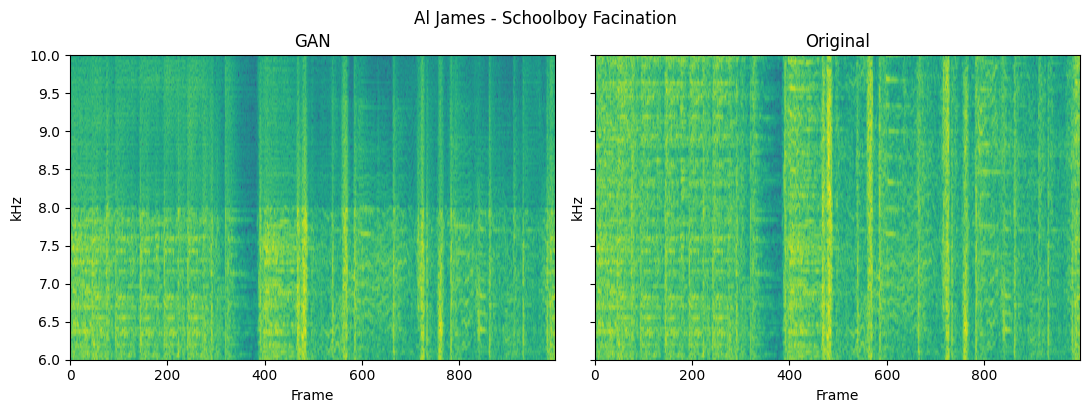

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\gan_crossover_test00.png


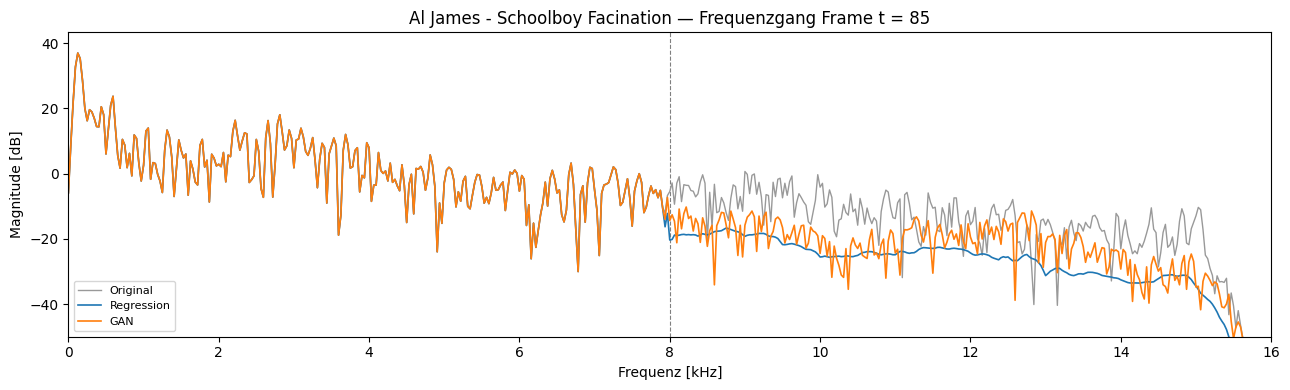

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\modelle_frequenzgang_test00_t85.png


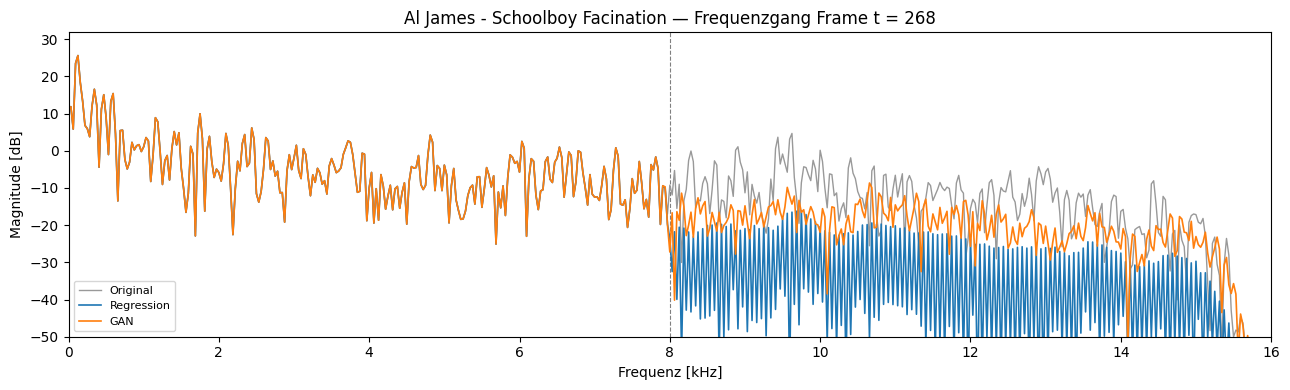

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\modelle_frequenzgang_test00_t268.png


=== Enda Reilly - Cur An Long Ag Seol ===


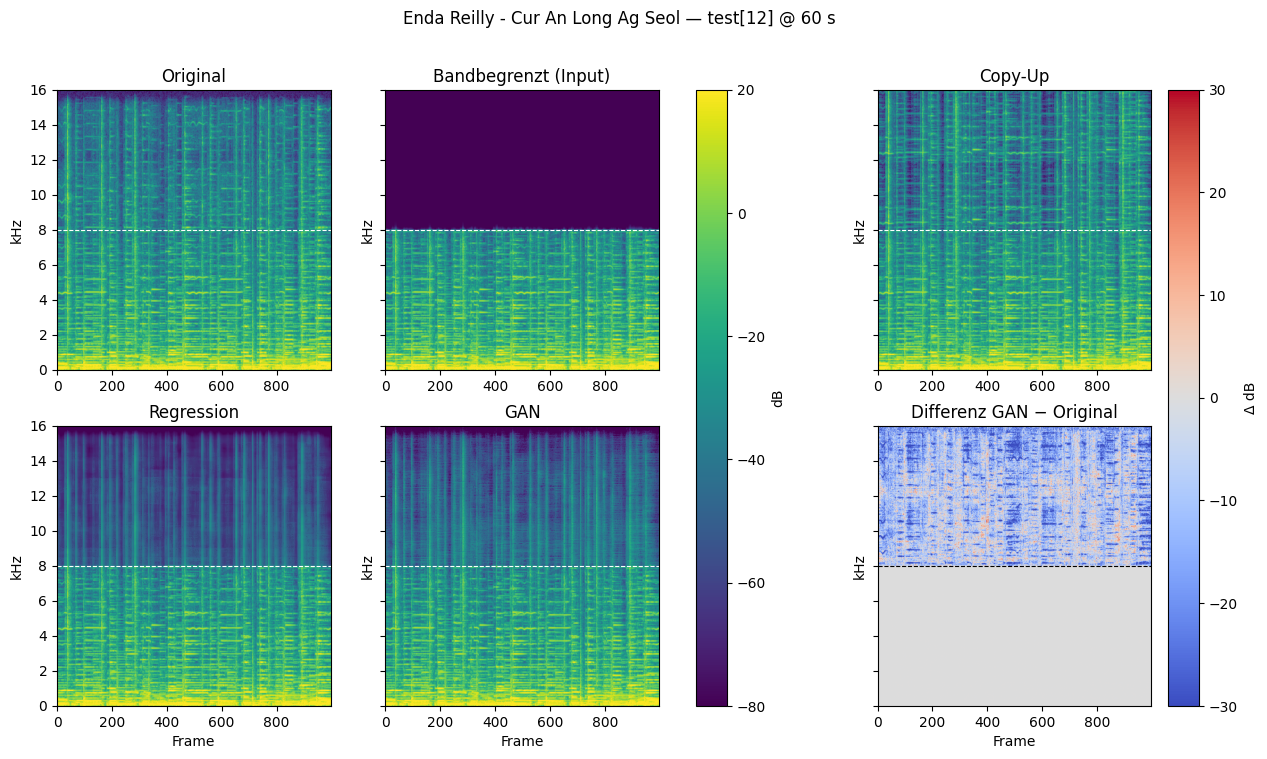

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\modelle_grid_test12.png


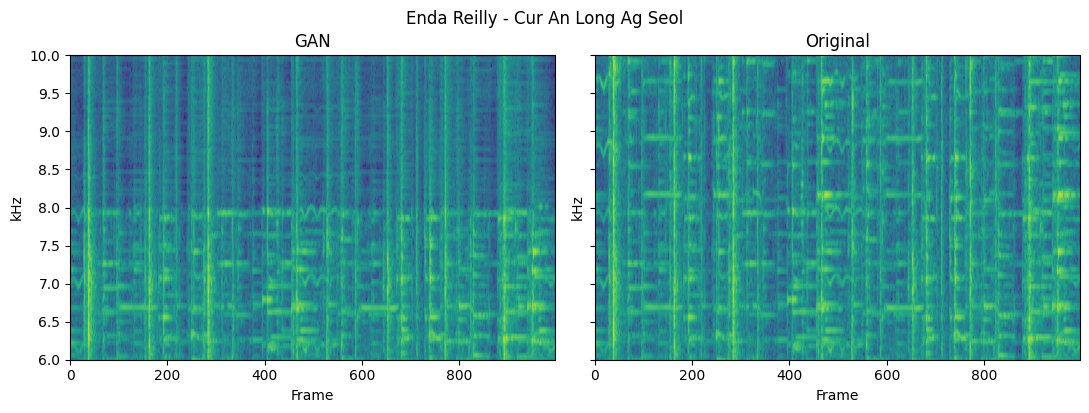

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\gan_crossover_test12.png


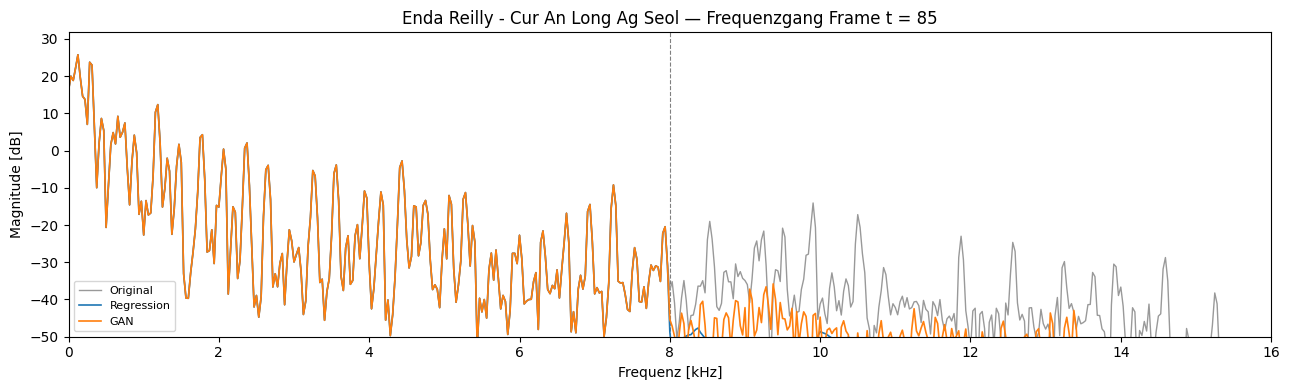

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\modelle_frequenzgang_test12_t85.png


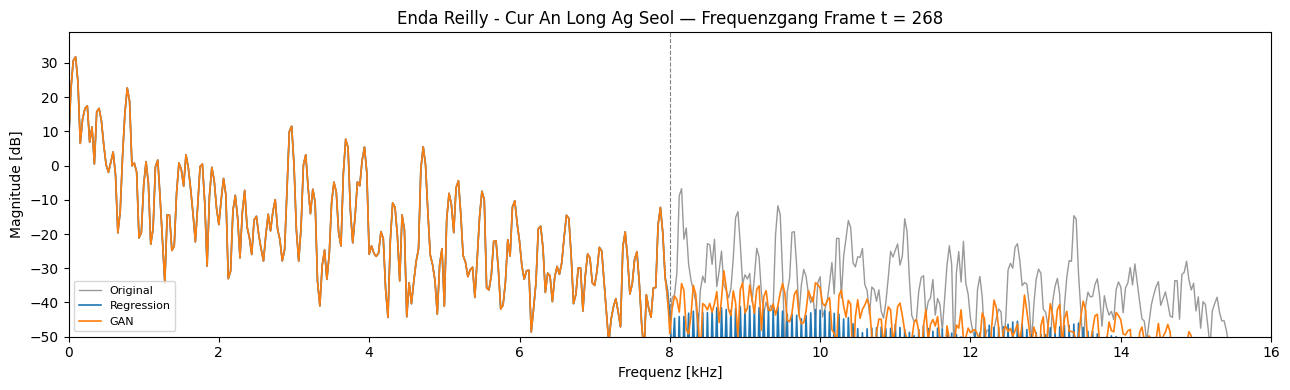

  gespeichert: C:\Users\danyr\OneDrive\Dokumente\alfatraining\DeepLearning\Projektarbeit\praesentation\plots\modelle_frequenzgang_test12_t268.png


In [5]:
# >>> Auswahl: (split, index, offset_s, dauer_s) + Frames für die Frequenzgänge <<<
GRID_DEMOS = [
    ("test",  0, 30.0, 8.0),
    ("test", 12, 60.0, 8.0),
]
T0S = (85, 268)

for split, index, offset, seconds in GRID_DEMOS:
    name, target = load_demo(split, index, seconds=seconds, offset=offset)
    cu, inp = baseline_from_fullband(target)
    reg, _ = model_from_fullband(g_reg, target)
    gan, _ = model_from_fullband(g_gan, target)
    key = f"{split}{index:02d}"
    print(f"=== {name} ===")

    fig = P.spectro_grid6(target, inp, cu, reg, gan,
                          suptitle=f"{name} — {split}[{index}] @ {offset:.0f} s")
    plt.show()
    save_fig(fig, f"modelle_grid_{key}.png")

    fig = P.crossover_zoom(gan, target, titles=("GAN", "Original"))
    fig.suptitle(name, y=1.02)
    plt.show()
    save_fig(fig, f"gan_crossover_{key}.png")

    for t0 in T0S:
        fig = P.frame_response(
            [("Original", target, dict(color="0.6", lw=1.0)),
             ("Regression", reg, dict(color="C0", lw=1.2)),
             ("GAN", gan, dict(color="C1", lw=1.2))],
            t0=t0, title=f"{name} — Frequenzgang Frame t = {t0}")
        plt.show()
        save_fig(fig, f"modelle_frequenzgang_{key}_t{t0}.png")

## Fazit

- Das Raster zeigt die zentrale Story auf einen Blick: leeres HF-Band → grobe Kopie
  (Copy-Up) → verwaschene Mittelung (Regression) → scharfe, plausible Textur (GAN).
- Der Differenz-Plot (GAN−Original) macht ehrlich sichtbar, dass das GAN *plausible*,
  nicht *identische* HF erzeugt.
- Frequenzgang-Frames sind das beste Detail-Argument gegen die Regression: ihre
  HF-Hüllkurve fällt zu früh ab (Mittelungs-Loss), das GAN hält das Niveau des
  Originals.